# ML_Assignment_1

## Hourly Bike Rental Demand Forecasting

### Student Information

* **Name**:_________*Pankaj Singh Rawat*
* **Roll Number**:__*2025ac05533*
* **Course**:_______*BITS M.Tech (AI&ML)*
* **Subject**:______*Machine Learning / ML*
* **Assignment**:___*Assignment 1*


**Goal:** The aim of this assignment is to forecast the total number of bicycle rentals per hour by leveraging weather conditions, time-of-day information, and seasonal variables.

**Prediction Target:** count (hourly total bike rental volume)


## Table of Contents

*    1. [Load Data](#section_1)
*    2. [Data pre-processing](#section_2)
*    3. [Exploratory Data Analysis (EDA) with Visualization](#section_3)
        *   [3A. General descriptive analysis of dataset](#section_3a)
        *   [3B. Distribution of target variable (`count`)](#section_3b)
        *   [3C. Relationship between categorical columns and target variable (`count`)](#section_3c)
        *   [3D. Relationship between numerical columns and target variable (`count`)](#section_3d)
        *   [3E. Check correlation among features](#section_3e)
        *   [3F. Observations and summary](#section_3f)
*    4. [Feature Selection and Engineering](#section_4)
*    5. [Regression Models (Model Evaluations and Selection)](#section_5)
*    6. [Test data](#section_6)
*    7. [Predictions](#section_7)
*    8. [Assignment Questions (Q&A)](#section_8)


## <a id='section_1'>1. Load Data</a>


In [1]:
import pandas as pd
pd.set_option('display.max_columns', 50)

train_data = pd.read_csv('bike_train.csv')
train_data.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2012-07-15 7:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,17,30,47
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,84,199,283
2,2011-02-06 6:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,0,1,1
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,198,330,531
4,2012-01-09 2:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,2,3,5


#### **Column Descriptions**

* **datetime**: Timestamp for each record, encoding year, month, day, hour, minute, and second information.

* **season**: The season in which the observation was captured.

* **holiday**: A flag indicating whether the given day falls on a public holiday.

    - 1 = Public holiday

    - 0 = Regular day

* **workingday**: Indicates if the day is a standard working day.

    - 1 = Working day

    - 0 = Holiday or weekend

* **weather**: The prevailing weather conditions at the time of observation.

* **temp**: Measured temperature in degrees Celsius.

* **atemp**: Perceived or apparent temperature in degrees Celsius.

* **humidity**: Relative humidity percentage at the time of observation.

* **windspeed**: Recorded wind speed at the time of observation.

* **casual**: Count of bike rentals made by non-registered (casual) users.

* **registered**: Count of bike rentals made by registered users.

* **count**: Combined total of all bike rentals — this is the variable we aim to predict.


## <a id='section_2'>2. Data pre-processing</a>


In [2]:
## Drop columns that won't be used in model training
train_data = train_data.drop(columns=['casual','registered'])

In [3]:
## Parse datetime and derive temporal sub-fields to enable richer feature engineering.
train_data['datetime'] = pd.to_datetime(train_data['datetime'],dayfirst=True)
train_data['year'] = train_data['datetime'].dt.year
train_data['month'] = train_data['datetime'].dt.month
train_data['day'] = train_data['datetime'].dt.day
train_data['hour'] = train_data['datetime'].dt.hour
train_data['weekday'] = train_data['datetime'].dt.weekday
train_data['is_weekend'] = (train_data['weekday'] >= 5).astype(int)
train_data['peak_hour'] = train_data['hour'].isin([7,8,9,16,17,18,19]).astype(int)
train_data['temp_atemp_diff'] = train_data['temp'] - train_data['atemp']
train_data['temp_atemp_mean'] = (train_data['temp'] + train_data['atemp']) / 2
train_data['temp_humidity'] = train_data['temp'] * train_data['humidity']
train_data['humidity_windspeed'] = train_data['humidity'] * train_data['windspeed']
train_data['temp_windspeed'] = train_data['temp'] * train_data['windspeed']


/var/folders/06/hkr693g11w5664zqwdb59_2r0000gn/T/ipykernel_16028/1518950181.py:2: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  train_data['datetime'] = pd.to_datetime(train_data['datetime'],dayfirst=True)


In [4]:
## Display the training dataset after all preprocessing steps are complete
train_data.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,year,month,day,hour,weekday,is_weekend,peak_hour,temp_atemp_diff,temp_atemp_mean,temp_humidity,humidity_windspeed,temp_windspeed
0,2012-07-15 07:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,47,2012,7,15,7,6,1,1,-4.635000,31.017500,2267.300000,474.252800,172.291840
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,283,2012,8,14,15,1,0,0,-4.260000,35.750000,1546.520000,690.059800,504.343706
2,2011-02-06 06:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,1,2011,2,6,6,6,1,0,-2.220000,11.770000,639.600000,900.078000,159.913858
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,531,2012,5,6,17,6,1,1,-4.141106,28.495613,1611.928679,580.249551,251.362777
4,2012-01-09 02:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,5,2012,1,9,2,0,0,0,-2.280000,10.980000,551.040000,503.893600,88.541304


## <a id='section_3'>3. Exploratory Data Analysis (EDA) with Visualization</a>


### <a id='section_3a'>3A. General descriptive analysis of dataset</a>


In [5]:
# Check the number of rows and columns
print(train_data.shape)

# Check the data types of each column
print(train_data.dtypes)

# Check for missing values
print(train_data.isnull().sum())

(10450, 22)
datetime              datetime64[us]
season                         int64
holiday                        int64
workingday                     int64
weather                        int64
temp                         float64
atemp                        float64
humidity                       int64
windspeed                    float64
count                          int64
year                           int32
month                          int32
day                            int32
hour                           int32
weekday                        int32
is_weekend                     int64
peak_hour                      int64
temp_atemp_diff              float64
temp_atemp_mean              float64
temp_humidity                float64
humidity_windspeed           float64
temp_windspeed               float64
dtype: object
datetime              0
season                0
holiday               0
workingday            0
weather               0
temp                  0
atemp           

### <a id='section_3b'>3B. Distribution of target variable (`count`)</a>


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

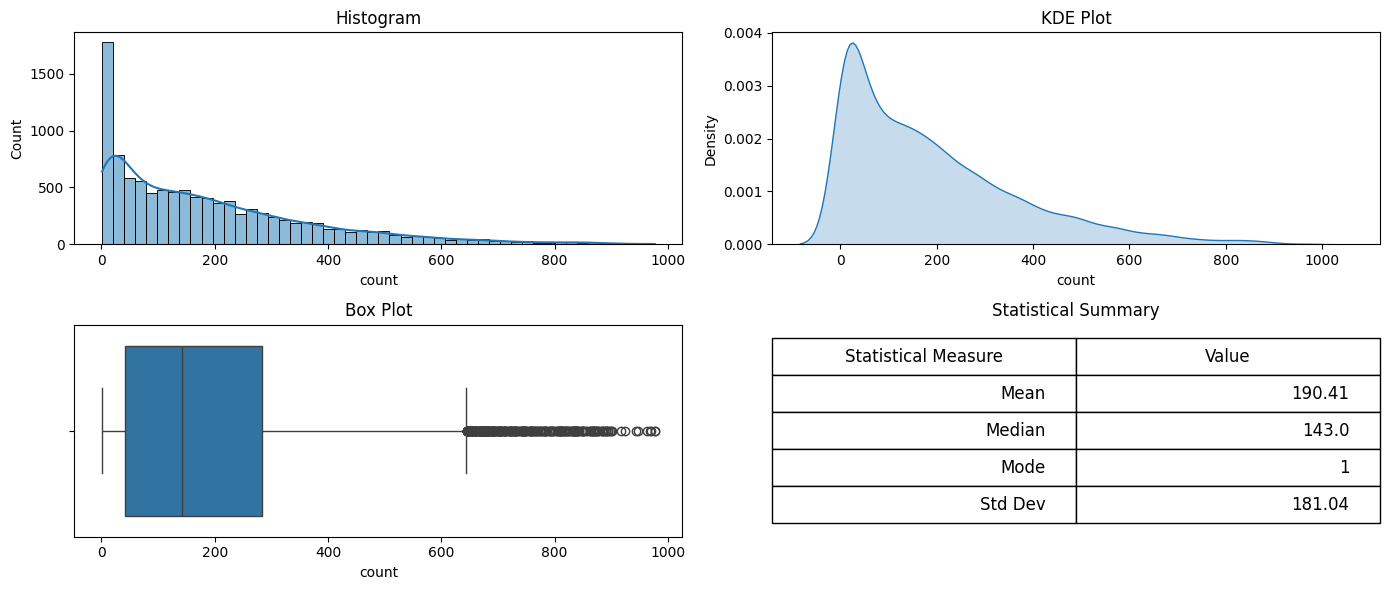

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14,6))

# Histogram
sns.histplot(train_data['count'], bins=50, kde=True, ax=axes[0,0])
axes[0,0].set_title('Histogram')

# KDE Plot
sns.kdeplot(train_data['count'], fill=True, ax=axes[0,1])
axes[0,1].set_title('KDE Plot')

# Box Plot
sns.boxplot(x=train_data['count'], ax=axes[1,0])
axes[1,0].set_title('Box Plot')

# Statistical summary
axes[1,1].axis('off')
stats_tab = [
    ['Mean', round(train_data['count'].mean(), 2)],
    ['Median', round(train_data['count'].median(), 2)],
    ['Mode', round(train_data['count'].mode()[0], 2)],
    ['Std Dev', round(train_data['count'].std(), 2)]
]
stats_table = axes[1,1].table(
    cellText=stats_tab,
    colLabels=['Statistical Measure', 'Value'],
    loc='center'
)
stats_table.auto_set_font_size(False)
stats_table.set_fontsize(12)
stats_table.scale(1, 2.2)
axes[1,1].set_title('Statistical Summary')

plt.tight_layout()
plt.show()

In [8]:
## Partition columns into categorical and numerical groups for separate association analysis with the target
target_col = 'count'
id_cols = 'datetime'
cat_cols = ['season','holiday','workingday','weather','year','month','day','hour']
num_cols = ['temp','atemp','humidity','windspeed']

### <a id='section_3c'>3C. Relationship between categorical columns and target variable (`count`)</a>

*   Use ANOVA (F-statistic) to quantify how strongly each category separates rental volumes


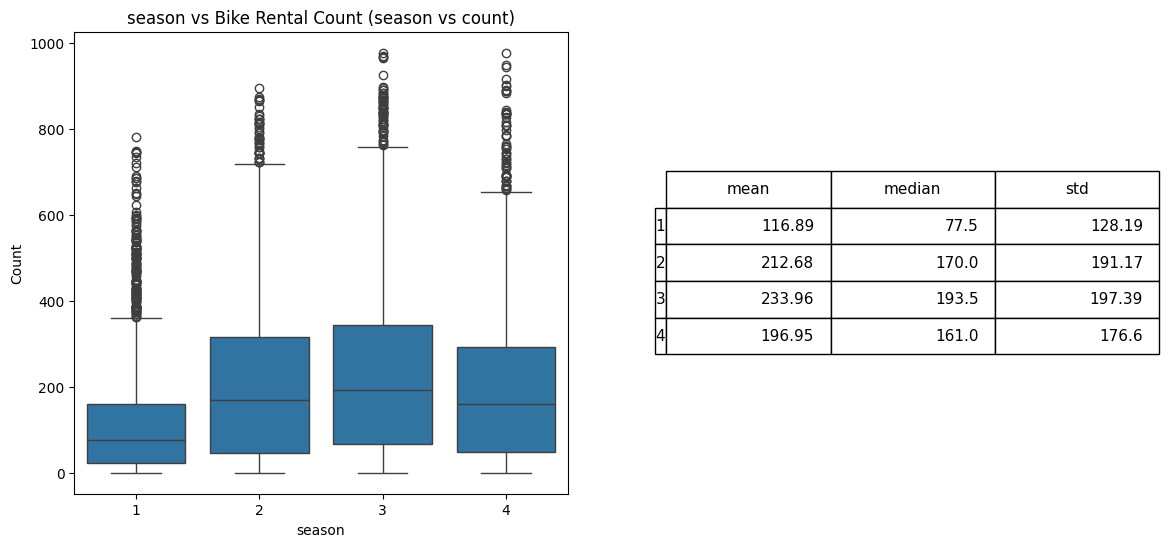

<Figure size 800x600 with 0 Axes>

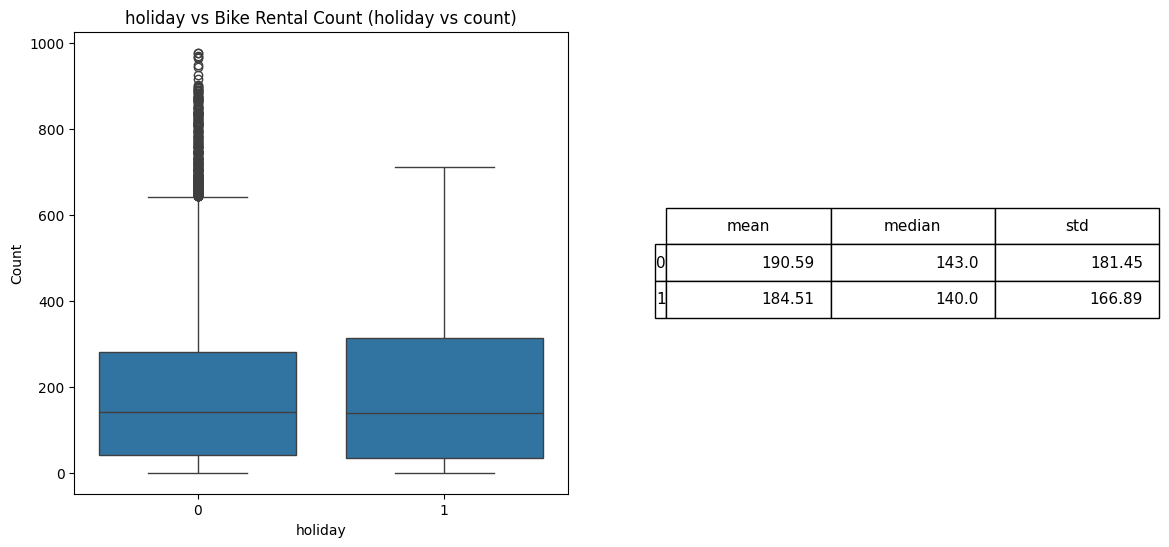

<Figure size 800x600 with 0 Axes>

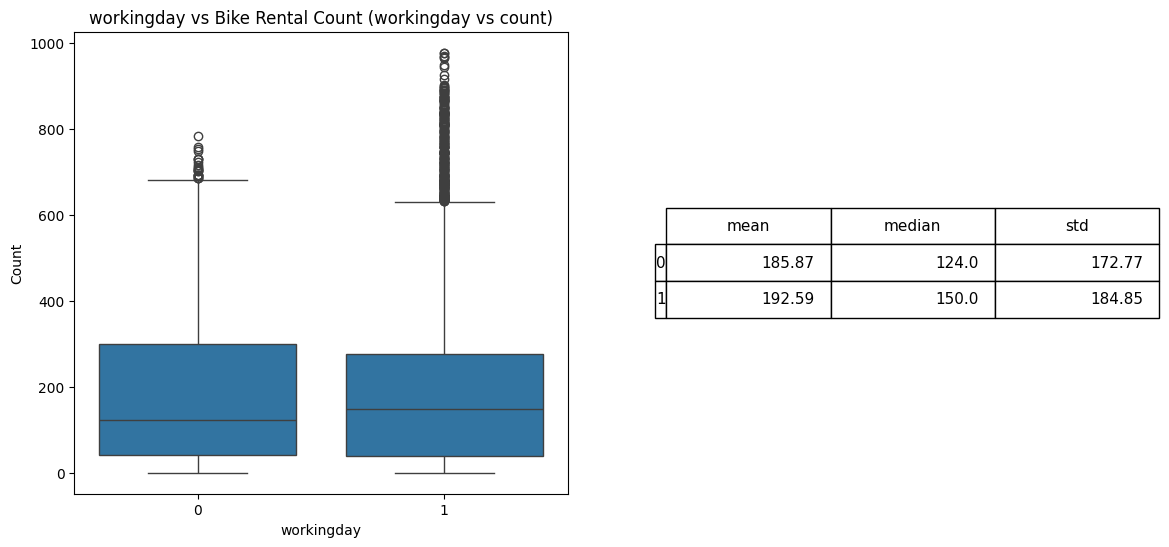

<Figure size 800x600 with 0 Axes>

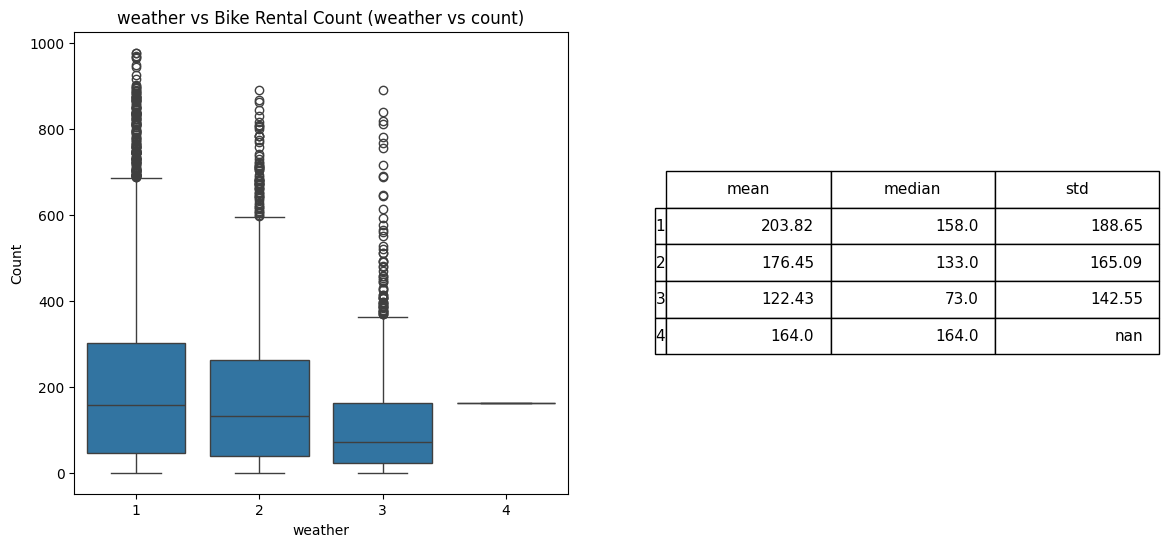

<Figure size 800x600 with 0 Axes>

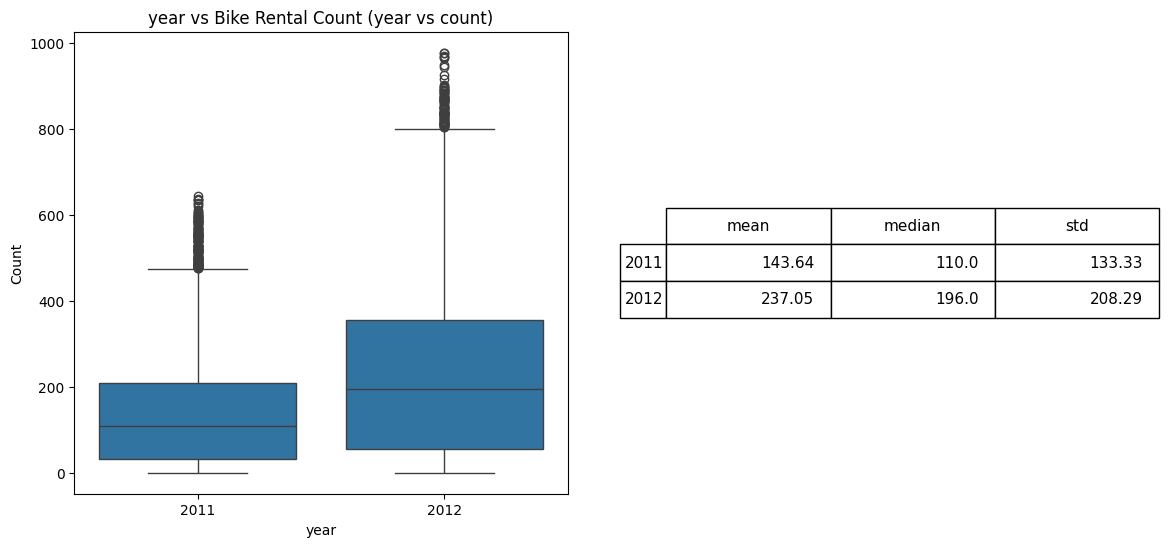

<Figure size 800x600 with 0 Axes>

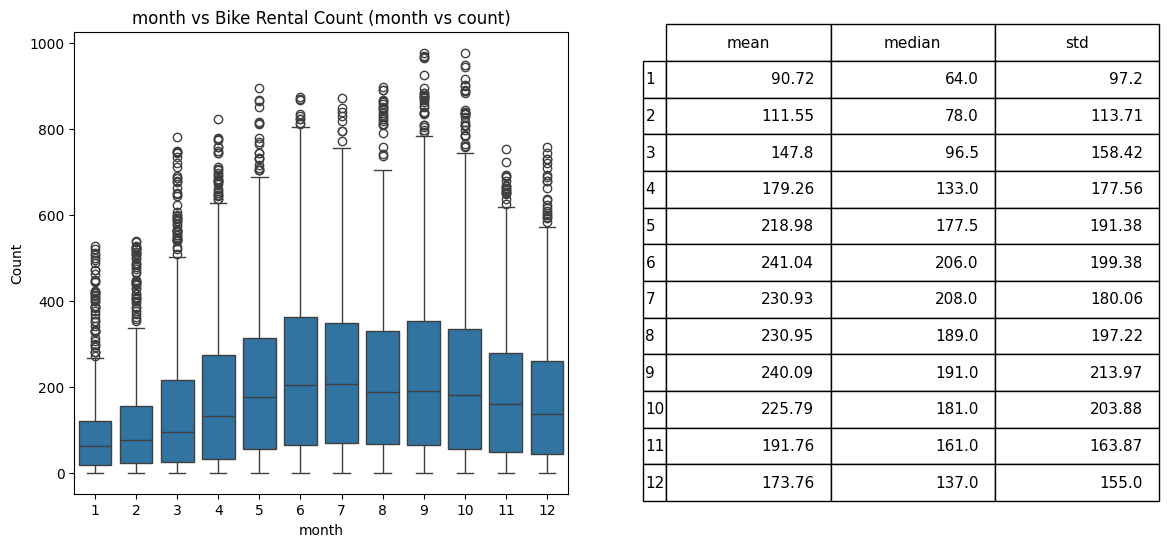

<Figure size 800x600 with 0 Axes>

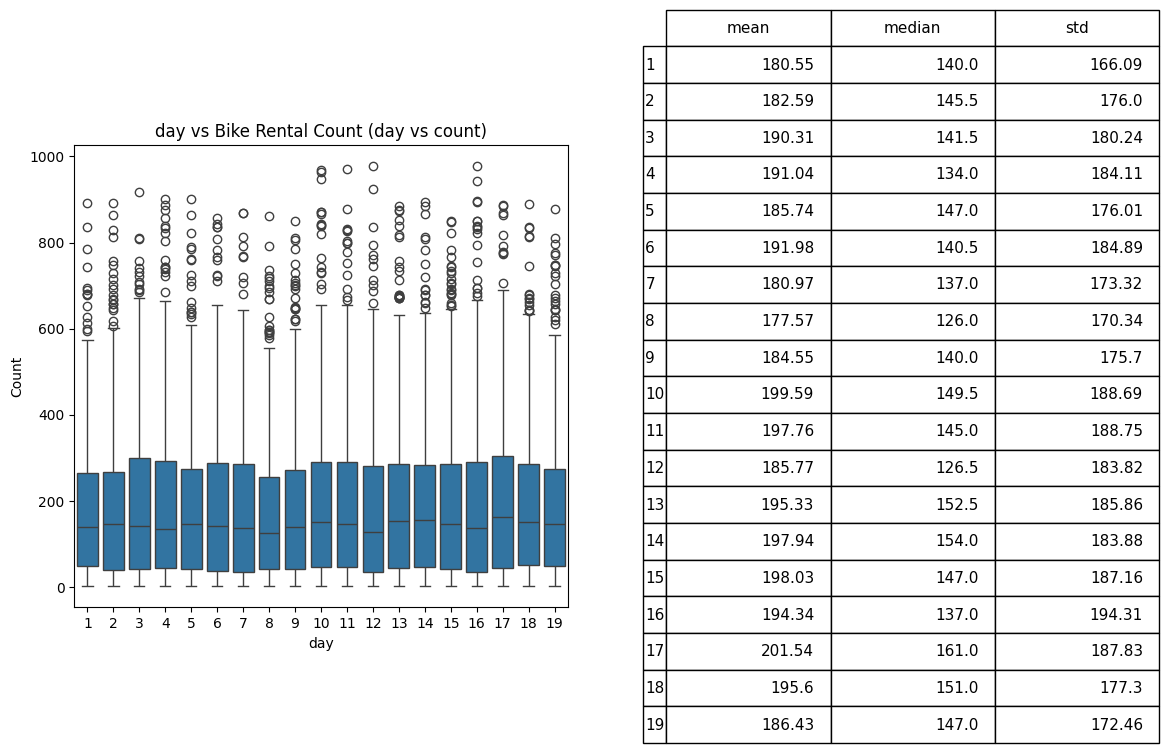

<Figure size 800x600 with 0 Axes>

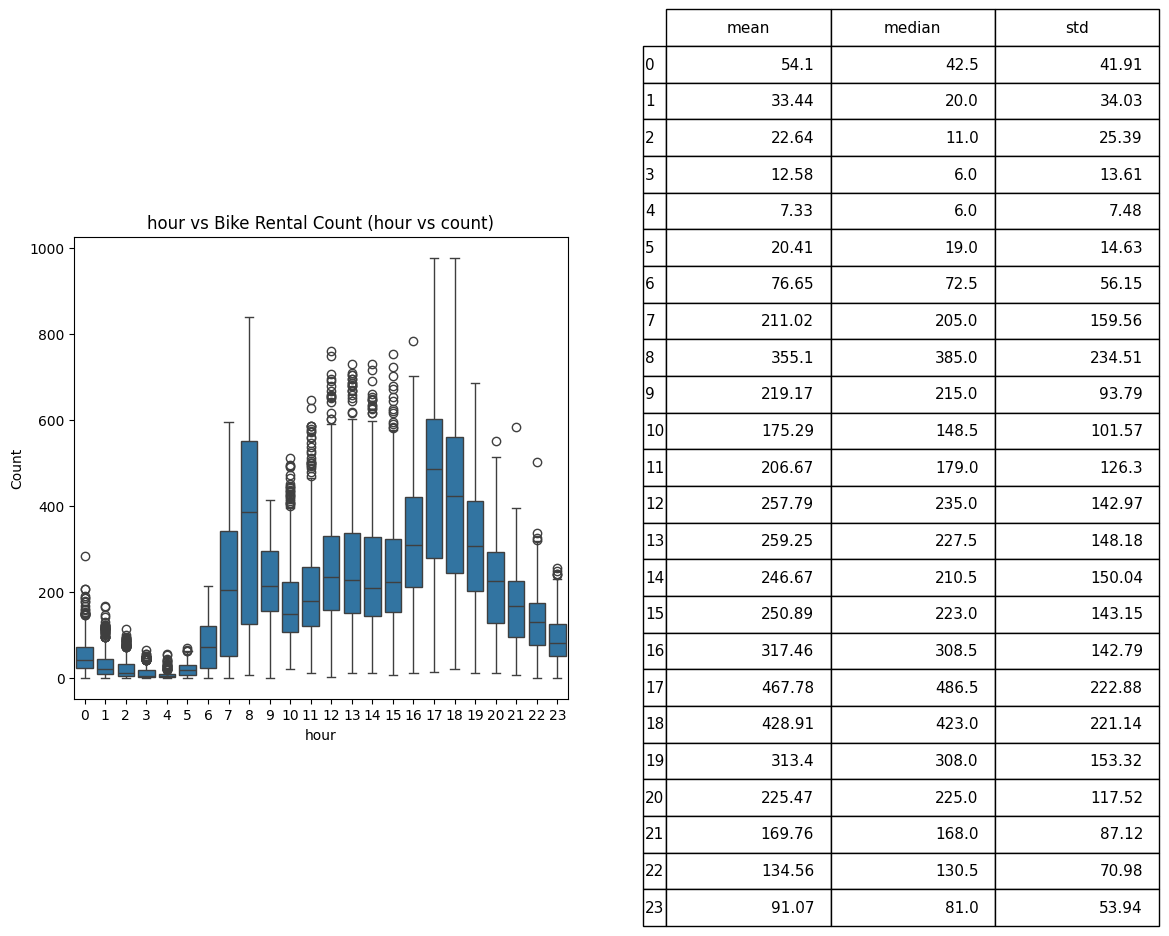

<Figure size 800x600 with 0 Axes>

In [9]:
## For each categorical column, render a box plot and a descriptive statistics table relative to the target 'count'
for col in cat_cols:
    fig, axes = plt.subplots(1,2, figsize=(14,6))
    plt.figure(figsize=(8,6))

    sns.boxplot(x=col, y='count', data=train_data, ax=axes[0])
    axes[0].set_title(f'{col} vs Bike Rental Count ({col} vs count)')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Count')

    axes[1].axis('off')
    cat_stats = train_data.groupby(col)['count'].agg(['mean', 'median', 'std']).round(2)
    cat_stats_table = axes[1].table(
        cellText=cat_stats.values,
        rowLabels=cat_stats.index,
        colLabels=cat_stats.columns,
        loc='center'
    )
    cat_stats_table.auto_set_font_size(False)
    cat_stats_table.set_fontsize(11)
    cat_stats_table.scale(1, 2.2)

    plt.tight_layout()
    plt.show()

In [10]:
## Measure how strongly each categorical feature relates to 'count' via the ANOVA F-test and associated p-values
from scipy.stats import f_oneway

cat_cols_association_results = []
for col in cat_cols:
    groups = [group[target_col].values for _, group in train_data.groupby(col)]

    f_stat, p_value = f_oneway(*groups)
    cat_cols_association_results.append({
        'Feature': col,
        'F-Statistic': round(f_stat, 2),
        'P-Value': round(p_value, 6),
        'Significance': 'Strong' if p_value < 0.05 else 'Weak'
    })

cat_cols_association_df = pd.DataFrame(cat_cols_association_results)
cat_cols_association_df = cat_cols_association_df.sort_values(by='P-Value')
cat_cols_association_df

,Feature,F-Statistic,P-Value,Significance
0,season,219.97,0.000000,Strong
3,weather,57.39,0.000000,Strong
4,year,744.97,0.000000,Strong
5,month,74.00,0.000000,Strong
7,hour,484.91,0.000000,Strong
2,workingday,3.15,0.075955,Weak
1,holiday,0.33,0.566027,Weak
6,day,0.89,0.595176,Weak


### <a id='section_3d'>3D. Relationship between numerical columns and target variable (`count`)</a>

*   Apply Pearson's correlation coefficient to measure linear association strength


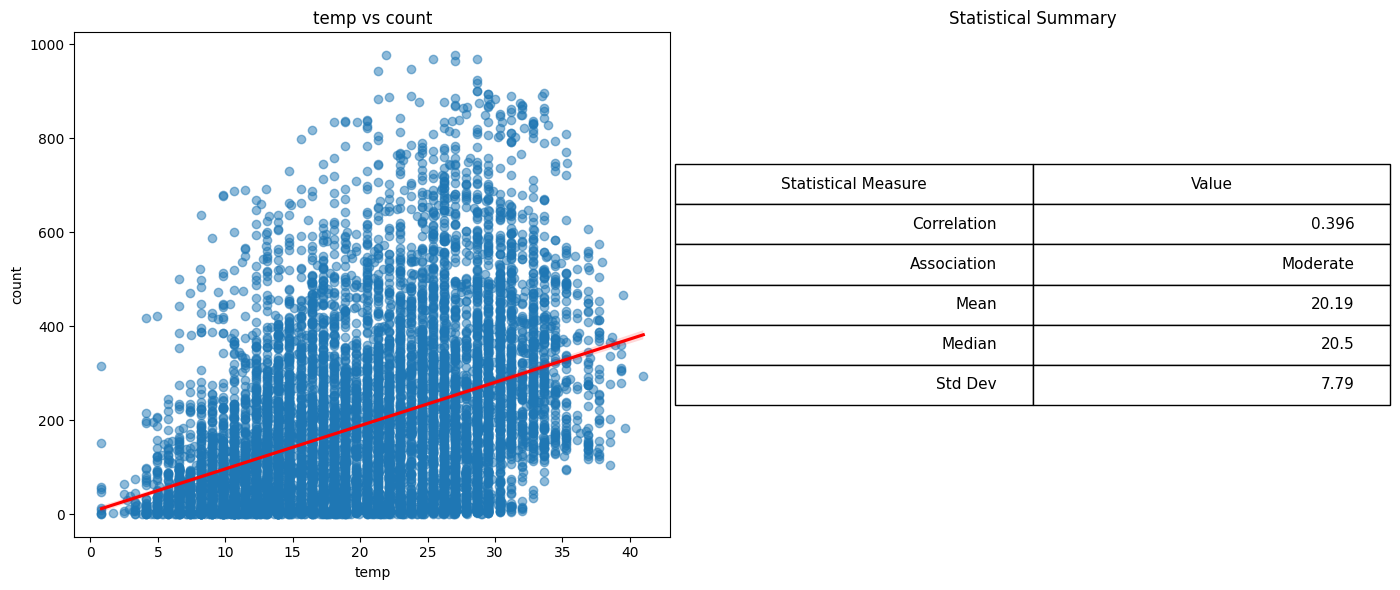

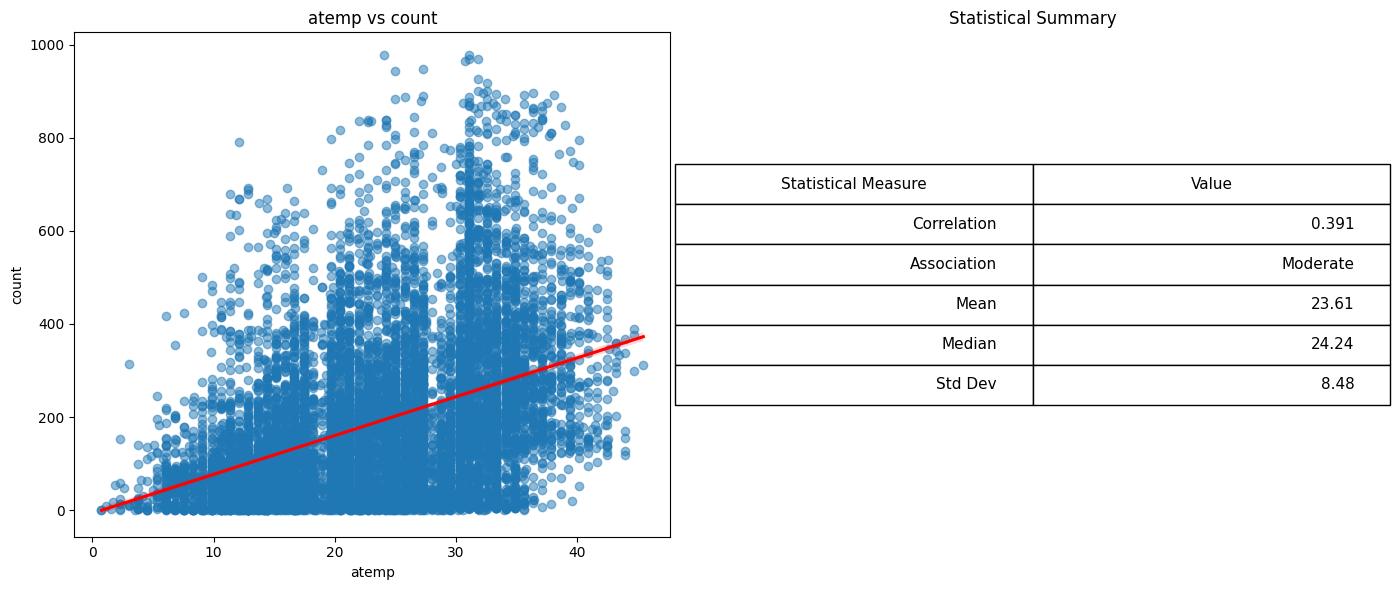

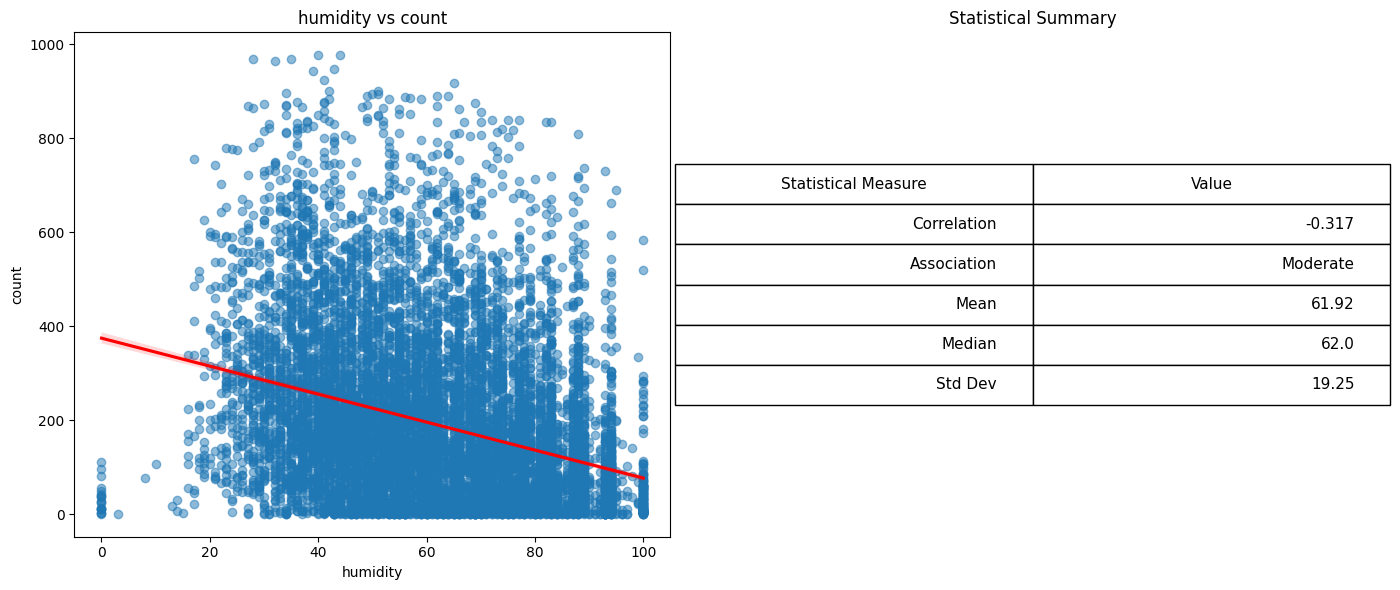

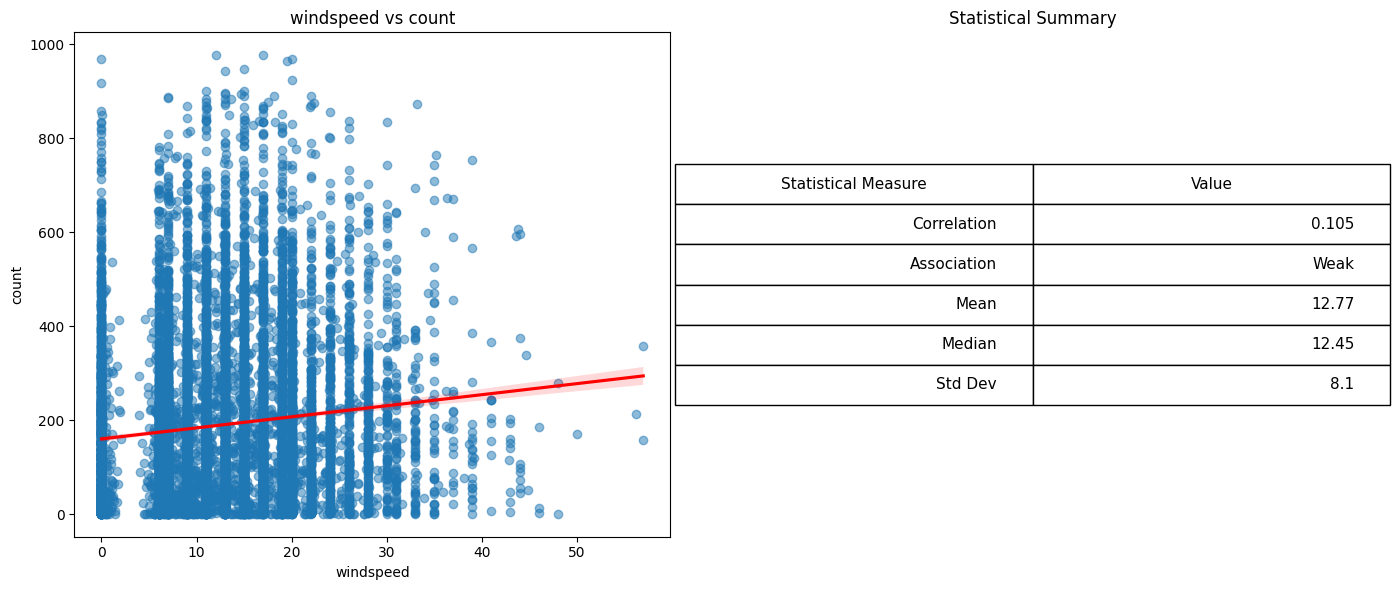

In [11]:
num_cols_association_results = []
for col in num_cols:
    fig, axes = plt.subplots(1,2, figsize=(14,6))
    sns.regplot(
        x=col,
        y=target_col,
        data=train_data,
        scatter_kws={'alpha':0.5},
        line_kws={'color':'red'},
        ax=axes[0]
    )
    axes[0].set_title(f'{col} vs {target_col}')
    corr = train_data[col].corr(train_data[target_col])
    mean_val = train_data[col].mean()
    median_val = train_data[col].median()
    std_val = train_data[col].std()

    strength = (
        'Strong'
        if abs(corr) >= 0.7 else
        'Moderate'
        if abs(corr) >= 0.3 else
        'Weak'
    )

    stats_table = pd.DataFrame({
        'Statistical Measure': [
            'Correlation',
            'Association',
            'Mean',
            'Median',
            'Std Dev'
        ],
        'Value': [
            round(corr, 3),
            strength,
            round(mean_val, 2),
            round(median_val, 2),
            round(std_val, 2)
        ]
    })

    axes[1].axis('off')

    table = axes[1].table(
        cellText=stats_table.values,
        colLabels=stats_table.columns,
        loc='center'
    )

    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 2.2)

    axes[1].set_title('Statistical Summary')

    plt.tight_layout()
    plt.show()

### <a id='section_3e'>3E. Check correlation among features</a>

*   `temp` vs `atemp`
*   `holiday` vs `workingday`


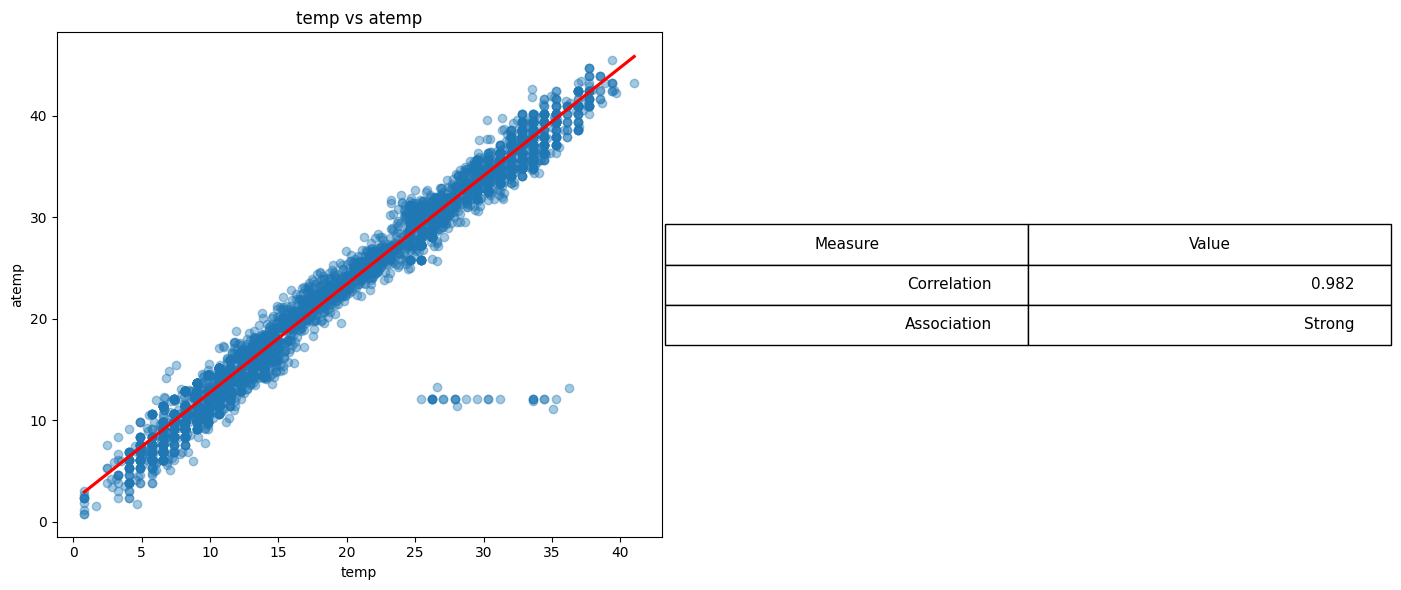

In [12]:
fig, axes = plt.subplots(1,2, figsize=(14,6))
sns.regplot(
    x='temp',
    y='atemp',
    data=train_data,
    scatter_kws={'alpha':0.4},
    line_kws={'color':'red'},
    ax=axes[0]
)

axes[0].set_title('temp vs atemp')
corr = train_data['temp'].corr(train_data['atemp'])
stats_table = pd.DataFrame({
    'Measure':['Correlation','Association'],
    'Value':[
        round(corr,3),
        'Strong' if abs(corr)>=0.7 else 'Moderate'
    ]
})

axes[1].axis('off')
table = axes[1].table(
    cellText=stats_table.values,
    colLabels=stats_table.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2,2.2)

plt.tight_layout()
plt.show()

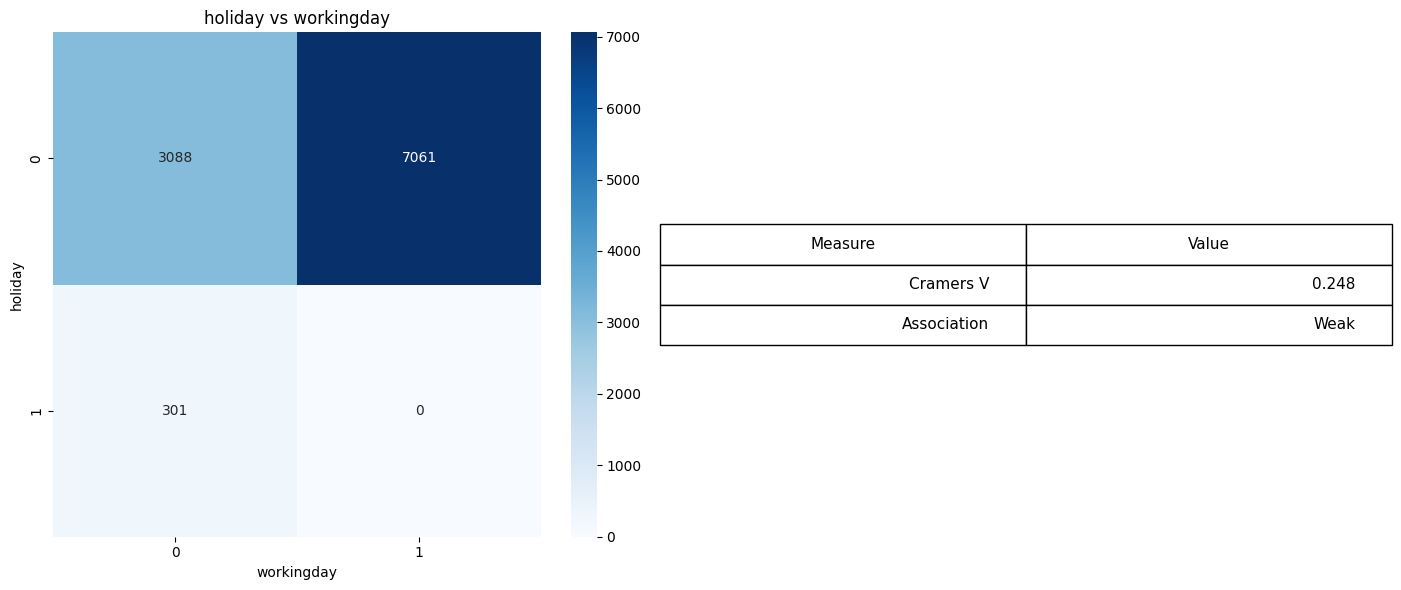

In [13]:
from scipy.stats import chi2_contingency
import numpy as np

fig, axes = plt.subplots(1,2, figsize=(14,6))
cross_tab = pd.crosstab(
    train_data['holiday'],
    train_data['workingday']
)

sns.heatmap(
    cross_tab,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)

axes[0].set_title('holiday vs workingday')
chi2, p_value, _, _ = chi2_contingency(cross_tab)
n = cross_tab.sum().sum()
cramers_v = np.sqrt(
    chi2 / (n * (min(cross_tab.shape)-1))
)
stats_table = pd.DataFrame({
    'Measure':['Cramers V','Association'],
    'Value':[
        round(cramers_v,3),
        'Strong' if cramers_v>=0.5 else
        'Moderate' if cramers_v>=0.3 else
        'Weak'
    ]
})

axes[1].axis('off')
table = axes[1].table(
    cellText=stats_table.values,
    colLabels=stats_table.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2,2.2)

plt.tight_layout()
plt.show()

### <a id='section_3f'>3F. **Observations and Summary**</a>



* **Dataset overview:**

    * The training dataset holds roughly 10,000 records with 12 columns, including the target column `count`.

    * The `datetime` column needs conversion from string to a proper datetime format to enable time-based analysis and downstream feature extraction.

    * No missing values were detected anywhere in the dataset.

* **Feature-target associations:**

    * Both the histogram and KDE plot of `count` exhibit right-skewed distributions, meaning a majority of rental counts are clustered toward lower values.

    * ANOVA F-statistics and box plots reveal that categorical features like `season` and `weather` exert a meaningful effect on rental volume.

    * Pearson correlation and regression plots confirm that temperature-related features share a positive relationship with demand, whereas humidity shows a comparatively weaker or slightly negative correlation.

    * Certain feature-target relationships appear non-linear, suggesting that a purely linear model may not fully exploit the underlying data structure.

* **Inter-feature correlations:**

    * A high correlation between `temp` and `atemp` signals multicollinearity, which can destabilize coefficient estimates in linear models.

    * `holiday` and `workingday` exhibit some association since holidays typically coincide with non-working days.

    * Pronounced correlation among several features suggests that regularization methods could enhance model stability and generalization.

* **Key takeaways:**

    * Temporal, seasonal, and weather-related features appear to be the most predictive variables for bike rental demand.

    * A baseline Simple Linear Regression model will be used first to assess the extent of linear structure in the data.

    * Polynomial Regression will be explored to accommodate potential nonlinear patterns in feature-target relationships.

    * Ridge Regression can address multicollinearity among correlated numerical features, and Lasso Regression can simultaneously perform automatic feature selection.

    * Feature engineering steps such as extracting `hour`, `month`, and `weekday` from datetime and applying cyclic encoding can further boost model performance.


### Q1. Examine dataset size, missing values, and feature types.

The training dataset comprises approximately 10,000 records spanning multiple numerical and categorical features alongside the target variable `count`. Inspection via `.info()` and `.describe()` confirmed no missing values in any column, and all feature data types were verified.


## <a id='section_4'>4. Feature Selection and Engineering</a>


In [14]:
train_data.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,year,month,day,hour,weekday,is_weekend,peak_hour,temp_atemp_diff,temp_atemp_mean,temp_humidity,humidity_windspeed,temp_windspeed
0,2012-07-15 07:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,47,2012,7,15,7,6,1,1,-4.635000,31.017500,2267.300000,474.252800,172.291840
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,283,2012,8,14,15,1,0,0,-4.260000,35.750000,1546.520000,690.059800,504.343706
2,2011-02-06 06:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,1,2011,2,6,6,6,1,0,-2.220000,11.770000,639.600000,900.078000,159.913858
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,531,2012,5,6,17,6,1,1,-4.141106,28.495613,1611.928679,580.249551,251.362777
4,2012-01-09 02:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,5,2012,1,9,2,0,0,0,-2.280000,10.980000,551.040000,503.893600,88.541304


In [15]:
## Encode periodic time-based columns using sine/cosine transformations to preserve their cyclic structure
def cyclic_transform(df, col, max_val):
    df[f'{col}_sin'] = np.sin(2 * np.pi * df[col] / max_val)
    df[f'{col}_cos'] = np.cos(2 * np.pi * df[col] / max_val)
    return df
time_cols = ['hour', 'day', 'month']
max_vals = {'hour': 24, 'day': 31, 'month': 12}
for col in time_cols:
    train_data = cyclic_transform(train_data, col, max_vals[col])
    del train_data[col]
train_data.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,year,weekday,is_weekend,peak_hour,temp_atemp_diff,temp_atemp_mean,temp_humidity,humidity_windspeed,temp_windspeed,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos
0,2012-07-15 07:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,47,2012,6,1,1,-4.635000,31.017500,2267.300000,474.252800,172.291840,0.965926,-2.588190e-01,0.101168,-0.994869,-0.500000,-0.866025
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,283,2012,1,0,0,-4.260000,35.750000,1546.520000,690.059800,504.343706,-0.707107,-7.071068e-01,0.299363,-0.954139,-0.866025,-0.500000
2,2011-02-06 06:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,1,2011,6,1,0,-2.220000,11.770000,639.600000,900.078000,159.913858,1.000000,6.123234e-17,0.937752,0.347305,0.866025,0.500000
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,531,2012,6,1,1,-4.141106,28.495613,1611.928679,580.249551,251.362777,-0.965926,-2.588190e-01,0.937752,0.347305,0.500000,-0.866025
4,2012-01-09 02:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,5,2012,0,0,0,-2.280000,10.980000,551.040000,503.893600,88.541304,0.500000,8.660254e-01,0.968077,-0.250653,0.500000,0.866025


In [16]:
## Retain 'year' as a feature — it is available in both training and test datasets and carries trend information.
train_data.head()


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,year,weekday,is_weekend,peak_hour,temp_atemp_diff,temp_atemp_mean,temp_humidity,humidity_windspeed,temp_windspeed,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos
0,2012-07-15 07:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,47,2012,6,1,1,-4.635000,31.017500,2267.300000,474.252800,172.291840,0.965926,-2.588190e-01,0.101168,-0.994869,-0.500000,-0.866025
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,283,2012,1,0,0,-4.260000,35.750000,1546.520000,690.059800,504.343706,-0.707107,-7.071068e-01,0.299363,-0.954139,-0.866025,-0.500000
2,2011-02-06 06:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,1,2011,6,1,0,-2.220000,11.770000,639.600000,900.078000,159.913858,1.000000,6.123234e-17,0.937752,0.347305,0.866025,0.500000
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,531,2012,6,1,1,-4.141106,28.495613,1611.928679,580.249551,251.362777,-0.965926,-2.588190e-01,0.937752,0.347305,0.500000,-0.866025
4,2012-01-09 02:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,5,2012,0,0,0,-2.280000,10.980000,551.040000,503.893600,88.541304,0.500000,8.660254e-01,0.968077,-0.250653,0.500000,0.866025


In [17]:
## Convert categorical variables into binary indicator columns via one-hot encoding
train_data = pd.get_dummies(train_data, columns=['season','holiday','workingday','weather'], drop_first=True, dtype=int)
train_data.head()

,datetime,temp,atemp,humidity,windspeed,count,year,weekday,is_weekend,peak_hour,temp_atemp_diff,temp_atemp_mean,temp_humidity,humidity_windspeed,temp_windspeed,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,season_2,season_3,season_4,holiday_1,workingday_1,weather_2,weather_3,weather_4
0,2012-07-15 07:00:00,28.70000,33.335000,79,6.003200,47,2012,6,1,1,-4.635000,31.017500,2267.300000,474.252800,172.291840,0.965926,-2.588190e-01,0.101168,-0.994869,-0.500000,-0.866025,0,1,0,0,0,0,0,0
1,2012-08-14 15:00:00,33.62000,37.880000,46,15.001300,283,2012,1,0,0,-4.260000,35.750000,1546.520000,690.059800,504.343706,-0.707107,-7.071068e-01,0.299363,-0.954139,-0.866025,-0.500000,0,1,0,0,1,0,0,0
2,2011-02-06 06:00:00,10.66000,12.880000,60,15.001300,1,2011,6,1,0,-2.220000,11.770000,639.600000,900.078000,159.913858,1.000000,6.123234e-17,0.937752,0.347305,0.866025,0.500000,0,0,0,0,0,0,0,0
3,2012-05-06 17:00:02,26.42506,30.566166,61,9.512288,531,2012,6,1,1,-4.141106,28.495613,1611.928679,580.249551,251.362777,-0.965926,-2.588190e-01,0.937752,0.347305,0.500000,-0.866025,1,0,0,0,0,1,0,0
4,2012-01-09 02:00:00,9.84000,12.120000,56,8.998100,5,2012,0,0,0,-2.280000,10.980000,551.040000,503.893600,88.541304,0.500000,8.660254e-01,0.968077,-0.250653,0.500000,0.866025,0,0,0,0,1,0,0,0


In [18]:
## Cast all feature and target columns to float64 for numerical stability and broad algorithm compatibility
cols_to_convert = [col for col in train_data.columns if col != 'datetime']
train_data[cols_to_convert] = train_data[cols_to_convert].astype(float)
train_data.head()

,datetime,temp,atemp,humidity,windspeed,count,year,weekday,is_weekend,peak_hour,temp_atemp_diff,temp_atemp_mean,temp_humidity,humidity_windspeed,temp_windspeed,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,season_2,season_3,season_4,holiday_1,workingday_1,weather_2,weather_3,weather_4
0,2012-07-15 07:00:00,28.70000,33.335000,79.0,6.003200,47.0,2012.0,6.0,1.0,1.0,-4.635000,31.017500,2267.300000,474.252800,172.291840,0.965926,-2.588190e-01,0.101168,-0.994869,-0.500000,-0.866025,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2012-08-14 15:00:00,33.62000,37.880000,46.0,15.001300,283.0,2012.0,1.0,0.0,0.0,-4.260000,35.750000,1546.520000,690.059800,504.343706,-0.707107,-7.071068e-01,0.299363,-0.954139,-0.866025,-0.500000,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,2011-02-06 06:00:00,10.66000,12.880000,60.0,15.001300,1.0,2011.0,6.0,1.0,0.0,-2.220000,11.770000,639.600000,900.078000,159.913858,1.000000,6.123234e-17,0.937752,0.347305,0.866025,0.500000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2012-05-06 17:00:02,26.42506,30.566166,61.0,9.512288,531.0,2012.0,6.0,1.0,1.0,-4.141106,28.495613,1611.928679,580.249551,251.362777,-0.965926,-2.588190e-01,0.937752,0.347305,0.500000,-0.866025,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,2012-01-09 02:00:00,9.84000,12.120000,56.0,8.998100,5.0,2012.0,0.0,0.0,0.0,-2.280000,10.980000,551.040000,503.893600,88.541304,0.500000,8.660254e-01,0.968077,-0.250653,0.500000,0.866025,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


### Q4. Feature Engineering

Several feature engineering steps were applied: the datetime column was decomposed into constituent time units, cyclical encoding was used to represent periodic time features, one-hot encoding was applied to categorical variables, and a log transformation was performed on the target variable — all aimed at improving predictive model performance.


## <a id='section_5'>5. Regression Models (Model Evaluation and Selection)</a>


### Helper Function: Model Evaluation (RMSLE, Residual Plot, Coefficients)


In [19]:
def rmsle(y_true, y_pred):
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true))**2))

In [20]:
def evaluate_model(model,model_name,X_train,X_val,y_train,y_val,feature_names=None):

    model.fit(X_train,y_train)

    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    y_train_pred = np.maximum(0,y_train_pred)
    y_val_pred = np.maximum(0,y_val_pred)

    # y_train and y_val are stored in log1p space, so inverse-transform before RMSLE
    y_train_actual = np.expm1(y_train)
    y_val_actual = np.expm1(y_val)
    y_train_pred_actual = np.expm1(y_train_pred)
    y_val_pred_actual = np.expm1(y_val_pred)

    train_rmsle = rmsle(y_train_actual,y_train_pred_actual)
    val_rmsle = rmsle(y_val_actual,y_val_pred_actual)

    print(f'\n{model_name}')
    print('-'*40)
    print(f'\nTrain RMSLE: {train_rmsle:.4f}')
    print(f'Validation RMSLE: {val_rmsle:.4f}')

    residuals = y_val_actual - y_val_pred_actual

    plt.figure(figsize=(4,4))
    sns.scatterplot(x=y_val_pred_actual,y=residuals,alpha=0.5)
    plt.axhline(y=0,color='red',linestyle='--')

    plt.xlabel('Predicted Count')
    plt.ylabel('Residuals')
    plt.title(f'Residual Plot - {model_name}')
    plt.show()

    if feature_names is not None:

        coefficients_df = pd.DataFrame({
            'Feature': feature_names,
            'Coefficient': model.coef_
        })

        coefficients_df = coefficients_df.sort_values(by='Coefficient',ascending=False)
        display(coefficients_df.head(30))

    return {
        'Model': model_name,
        'Trained Model': model,
        'Hyperparameters': model.get_params(),
        'Train RMSLE': train_rmsle,
        'Validation RMSLE': val_rmsle
    }


### Training/Validation Split and Feature Scaling

The training data is partitioned into train and validation subsets. Feature scaling is then applied specifically for Polynomial, Lasso, and Ridge Regression models.


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.ensemble import HistGradientBoostingRegressor


In [22]:
X = train_data.drop(columns=[target_col,'datetime'])
y = np.log1p(train_data[target_col])

X_train,X_val,y_train,y_val = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

### Simple Linear Regression


In [23]:
from sklearn.linear_model import LinearRegression


Simple Linear Regression
----------------------------------------

Train RMSLE: 0.8257
Validation RMSLE: 0.8039


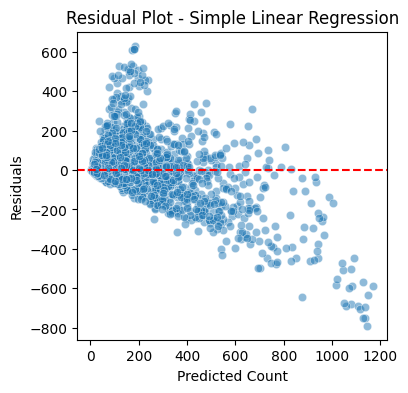

,Feature,Coefficient
7,peak_hour,0.354136
4,year,0.251443
21,season_4,0.238343
10,temp_humidity,0.135606
20,season_3,0.121103
19,season_2,0.103386
5,weekday,0.058909
11,humidity_windspeed,0.031415
12,temp_windspeed,0.026825
23,workingday_1,0.011815


In [24]:
slr_results = evaluate_model(
    model=LinearRegression(),
    model_name='Simple Linear Regression',
    X_train=X_train_scaled,
    X_val=X_val_scaled,
    y_train=y_train,
    y_val=y_val,
    feature_names=X_train.columns
)

### **Findings and Takeaways — Simple Linear Regression**

* **Model performance:**

    * Train and validation RMSLE values are close to each other, indicating the model is not overfitting the training data.

    * While the baseline performance is acceptable, the model is insufficient for capturing more intricate, non-linear patterns present in the dataset.

* **Residual analysis:**

    * After applying a log transformation to the target variable, residuals are more centered around zero than in the original scale.

    * Some systematic structure persists in the residuals, pointing to non-linear signals that the linear model cannot account for.

* **Feature coefficients:**

    * Time-based, temperature-related, and weather-related features all show measurable impact on bike rental volumes.

    * Correlated predictors like `temp` and `atemp` may still introduce instability in coefficient estimates.

* **Next steps:**

    * Simple Linear Regression serves as a useful starting point but is inherently limited in modeling non-linear dynamics.

    * The structured patterns remaining in the residuals suggest that a more expressive model class is warranted.

    * Polynomial Regression is a natural next step for capturing non-linear feature-target interactions more effectively.


### Q5. Training/Validation Split and Simple Linear Regression

Data was divided into training and validation portions using `train_test_split()`. A Simple Linear Regression model was trained as the initial baseline and evaluated primarily through RMSLE on the validation set.


### Polynomial Regression — Degree 2

A Polynomial Regression model of degree 2 was trained as an intermediate step, allowing comparison of generalization performance against the higher-complexity degree-3 variant.

The intent was to determine whether limiting polynomial complexity reduces overfitting and leads to better validation scores.


In [ ]:
poly2 = PolynomialFeatures(degree=2,include_bias=False)

X_train_poly2 = poly2.fit_transform(X_train_scaled)
X_val_poly2 = poly2.transform(X_val_scaled)

poly2_feature_names = poly2.get_feature_names_out(X_train.columns)


In [ ]:
poly2_results = evaluate_model(
    model=LinearRegression(),
    model_name='Polynomial Regression Degree 2',
    X_train=X_train_poly2,
    X_val=X_val_poly2,
    y_train=y_train,
    y_val=y_val,
    feature_names=poly2_feature_names
)

poly2_results


### **Findings and Takeaways — Polynomial Regression Degree 2**

* **Model performance:**

    * Degree-2 Polynomial Regression captures curved relationships between features and the target while maintaining lower model complexity than degree 3.

    * Validation RMSLE is expected to improve or remain more consistent owing to reduced risk of overfitting.

    * In comparison to degree 3, the degree-2 variant typically strikes a better bias-variance trade-off.

* **Generalization:**

    * Fewer polynomial terms mean a smaller feature space, which tends to yield more stable predictions on held-out data.

    * Degree-2 Polynomial Regression is often the preferred choice when degree-3 starts memorizing training noise.

* **Residual analysis:**

    * Residuals should be distributed more evenly around zero relative to Simple Linear Regression.

    * The model captures a portion of non-linearity without introducing excessive variance into predictions.


### Polynomial Regression — Degree 3


In [25]:
poly = PolynomialFeatures(degree=3,include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_val_poly = poly.transform(X_val_scaled)
poly_feature_names = poly.get_feature_names_out(X_train.columns)


Polynomial Regression
----------------------------------------

Train RMSLE: 0.3674
Validation RMSLE: 0.5758


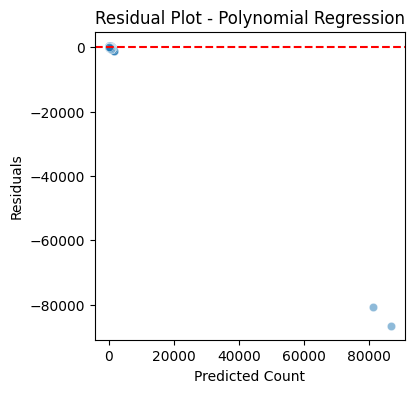

,Feature,Coefficient
1426,humidity season_2 holiday_1,5.386781
1718,windspeed month_cos holiday_1,5.083347
1688,windspeed day_sin holiday_1,4.667819
1433,humidity season_3 holiday_1,4.567763
1733,windspeed season_3 holiday_1,4.474510
3193,temp_humidity month_sin holiday_1,4.310638
1418,humidity month_cos holiday_1,4.242082
3118,temp_humidity humidity_windspeed holiday_1,3.353509
3172,temp_humidity day_sin holiday_1,3.342095
3133,temp_humidity temp_windspeed holiday_1,3.268421


In [26]:
poly_results = evaluate_model(
    model=LinearRegression(),
    model_name='Polynomial Regression',
    X_train=X_train_poly,
    X_val=X_val_poly,
    y_train=y_train,
    y_val=y_val,
    feature_names=poly_feature_names
)

### **Findings and Takeaways — Polynomial Regression (Degree 3)**

* **Model performance:**

    * Degree-3 Polynomial Regression delivered substantially lower train and validation RMSLE compared to Simple Linear Regression.

    * This model achieved the strongest validation RMSLE among all candidate models evaluated.

    * Train and validation metrics remain reasonably aligned, indicating that overfitting is kept within acceptable bounds despite added model complexity.

* **Residual analysis:**

    * Residuals are spread more randomly around zero compared to prior models, reflecting better modeling of non-linear relationships.

    * Residual variance is comparatively more homogeneous following polynomial feature expansion.

* **Feature coefficients:**

    * The polynomial expansion introduced interaction terms and higher-order transformations that enabled the model to detect complex patterns in bike rental demand.

    * Several of these derived interaction and transformation terms exhibit strong influence on predicted outputs.

* **Next steps:**

    * The substantial RMSLE gain confirms that non-linear dynamics are central to predicting bike rentals accurately.

    * Polynomial feature expansion proved more impactful than coefficient-based regularization for this prediction task.

    * Among all tested models, this one delivers the best combination of predictive accuracy and generalization.


### Lasso Regression


In [27]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

In [28]:
lasso_param_grid = {
    'alpha': [0.0001,0.001,0.01,0.1,1]
}

lasso_grid = GridSearchCV(
    estimator=Lasso(max_iter=10000),
    param_grid=lasso_param_grid,
    scoring='neg_mean_squared_error',
    cv=5
)

lasso_grid.fit(X_train_scaled,y_train)
best_lasso_model = lasso_grid.best_estimator_

print(lasso_grid.best_params_)

{'alpha': 0.0001}



Best Lasso Regression
----------------------------------------

Train RMSLE: 0.8257
Validation RMSLE: 0.8040


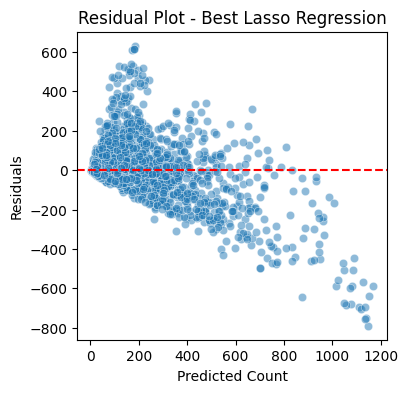

,Feature,Coefficient
7,peak_hour,0.354103
4,year,0.251238
21,season_4,0.237115
10,temp_humidity,0.129485
20,season_3,0.120042
19,season_2,0.103192
5,weekday,0.058485
11,humidity_windspeed,0.029260
12,temp_windspeed,0.022970
23,workingday_1,0.013314


In [29]:
lasso_results = evaluate_model(
    model=best_lasso_model,
    model_name='Best Lasso Regression',
    X_train=X_train_scaled,
    X_val=X_val_scaled,
    y_train=y_train,
    y_val=y_val,
    feature_names=X_train.columns
)

### **Findings and Takeaways — Lasso Regression**

* **Model performance:**

    * Lasso Regression yielded results broadly comparable to Simple Linear Regression across the evaluated range of regularization strengths (`alpha`).

    * Tuning `alpha` through cross-validation did not translate into a notable improvement in validation RMSLE.

* **Residual analysis:**

    * Residual distributions remained similar to those from Simple Linear Regression, indicating that L1 regularization alone could not address the underlying non-linear structure.

    * Simplifying the model via regularization did not produce a meaningful improvement in prediction quality.

* **Feature coefficients:**

    * Lasso regularization shrank weaker feature coefficients toward zero, effectively performing automatic variable selection.

    * Several coefficients were driven near zero, contributing to a leaner, simpler model structure.

* **Next steps:**

    * The results demonstrate that regularization and feature selection alone are insufficient to significantly boost predictive performance.

    * The key driver of improvement for this problem is capturing non-linearity, not coefficient shrinkage.

    * This is why Polynomial Regression outperformed Lasso Regression on this dataset.


### Ridge Regression


In [30]:
from sklearn.linear_model import Ridge

In [31]:
ridge_param_grid = {
    'alpha': [0.001,0.01,0.1,1,10,100]
}

ridge_grid = GridSearchCV(
    estimator=Ridge(),
    param_grid=ridge_param_grid,
    scoring='neg_mean_squared_error',
    cv=5
)

ridge_grid.fit(X_train_scaled,y_train)
best_ridge_model = ridge_grid.best_estimator_

print(ridge_grid.best_params_)

{'alpha': 10}



Best Ridge Regression
----------------------------------------

Train RMSLE: 0.8257
Validation RMSLE: 0.8040


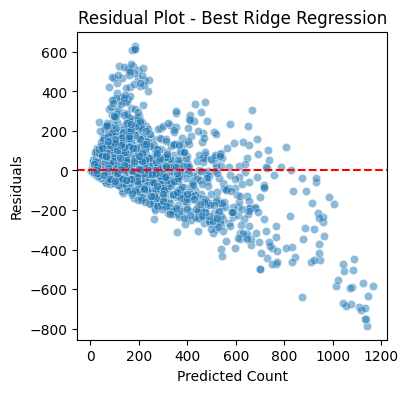

,Feature,Coefficient
7,peak_hour,0.354113
4,year,0.250910
21,season_4,0.235508
10,temp_humidity,0.129648
20,season_3,0.118660
19,season_2,0.103231
5,weekday,0.058770
11,humidity_windspeed,0.030179
12,temp_windspeed,0.024380
23,workingday_1,0.011754


In [32]:
ridge_results = evaluate_model(
    model=best_ridge_model,
    model_name='Best Ridge Regression',
    X_train=X_train_scaled,
    X_val=X_val_scaled,
    y_train=y_train,
    y_val=y_val,
    feature_names=X_train.columns
)

### **Findings and Takeaways — Ridge Regression**

* **Model performance:**

    * Ridge Regression produced performance nearly identical to Simple Linear Regression across different values of `alpha`.

    * Cross-validated hyperparameter tuning did not yield a substantial improvement in validation RMSLE.

* **Residual analysis:**

    * Residual patterns closely resembled those from Simple Linear Regression, indicating that L2 regularization did not resolve the non-linear component of the problem.

    * Coefficient shrinkage contributed to marginally more stable residual variance.

* **Feature coefficients:**

    * Ridge regularization dampened the coefficient instability arising from correlated features while retaining contributions from all variables.

    * Excessively large coefficient magnitudes were prevented, leading to more stable overall coefficient estimates.

* **Next steps:**

    * The findings suggest that multicollinearity was not the primary performance bottleneck for this problem.

    * The dominant source of improvement was modeling non-linear feature-target relationships rather than regularizing coefficients.

    * Polynomial Regression therefore emerges as the best-performing model among all linear approaches tested.



HistGradientBoosting Regression
----------------------------------------

Train RMSLE: 0.2682
Validation RMSLE: 0.3605


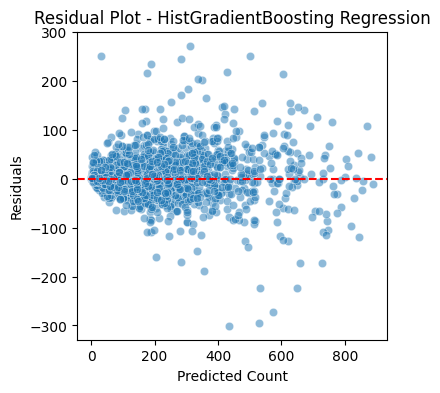

In [33]:
### HistGradientBoosting Regression
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_model = HistGradientBoostingRegressor(
    max_iter=400,
    learning_rate=0.05,
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)
hgb_results = evaluate_model(
    model=hgb_model,
    model_name='HistGradientBoosting Regression',
    X_train=X_train,
    X_val=X_val,
    y_train=y_train,
    y_val=y_val,
    feature_names=None
)

best_model = hgb_results['Trained Model']
best_model_name = hgb_results['Model']


### Summary: Model Comparison Table


### Q6. Improve model performance using Polynomial, Ridge, and Lasso Regression.

Polynomial features of degree 2 were introduced to capture non-linear patterns. Ridge and Lasso Regression models were also trained with grid-searched regularization strengths (`alpha`) to evaluate the contribution of regularization to predictive performance.


### Q7. Summarize results across all models.

All regression models were compared based on their validation RMSLE scores. Polynomial Regression delivered the top performance among all models evaluated in this assignment.


### Q8. Residual plot for the best-performing model.

Residuals from the best-performing Polynomial Regression model were examined to assess prediction quality and identify any remaining systematic patterns that the model failed to capture.


In [34]:
model_comparison_df = pd.DataFrame([slr_results, poly_results, lasso_results, ridge_results, hgb_results])
model_comparison_df = model_comparison_df.sort_values(by='Validation RMSLE')

display(model_comparison_df)


,Model,Trained Model,Hyperparameters,Train RMSLE,Validation RMSLE
4,HistGradientBoosting Regression,HistGradientBoostingRegressor(learning_rate=0....,"{'categorical_features': 'from_dtype', 'early_...",0.268217,0.360528
1,Polynomial Regression,LinearRegression(),"{'copy_X': True, 'fit_intercept': True, 'n_job...",0.367424,0.575813
0,Simple Linear Regression,LinearRegression(),"{'copy_X': True, 'fit_intercept': True, 'n_job...",0.825722,0.803895
3,Best Ridge Regression,Ridge(alpha=10),"{'alpha': 10, 'copy_X': True, 'fit_intercept':...",0.825726,0.803950
2,Best Lasso Regression,"Lasso(alpha=0.0001, max_iter=10000)","{'alpha': 0.0001, 'copy_X': True, 'fit_interce...",0.825724,0.803970


* **Models evaluated:** `Simple Linear Regression`, `Polynomial Regression (degree 3)`, `Lasso Regression`, `Ridge Regression`, and `HistGradientBoosting Regression`

* HistGradientBoosting Regression recorded the lowest validation RMSLE of all models tested.

* The gradient-boosted tree model proved more capable of learning non-linear patterns and seasonal effects present in the data, particularly after the feature engineering and cyclic encoding steps were applied.

* Applying a log transformation to the target variable helped stabilize variance and reduce skewness in rental counts, contributing to improved model performance.

* While regularization methods (Ridge and Lasso) were useful for studying the effect of coefficient shrinkage, neither outperformed the gradient boosting approach on this dataset.


### Q9. Explain why the winning model performs better.

HistGradientBoosting Regression outperforms the linear models because it can discover non-linear feature interactions and complex patterns without requiring explicit polynomial feature construction. Its ensemble boosting mechanism allows the model to leverage time-based engineered features and weather-season interactions far more effectively than linear or polynomial regression frameworks.


## <a id='section_6'>6. Test Data</a>


In [35]:
## Read the test dataset from disk
test_data = pd.read_csv('bike_test.csv')
test_df = test_data.copy()
test_df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,05-06-2012 5:00,2,0,1,3,19.680000,23.48500,82,11.00140
1,19-03-2011 19:00,1,0,0,1,18.040000,21.97000,33,19.00120
2,02-04-2012 6:00,2,0,1,1,13.885038,16.24664,68,29.52646
3,13-07-2012 20:00,3,0,1,1,30.340000,33.33500,48,8.99810
4,09-11-2011 19:00,4,0,1,1,18.040000,21.97000,72,7.00150


In [36]:
test_df.isnull().mean()

datetime      0.0
season        0.0
holiday       0.0
workingday    0.0
weather       0.0
temp          0.0
atemp         0.0
humidity      0.0
windspeed     0.0
dtype: float64

In [37]:
## Decompose the test set datetime column into the same temporal features constructed for training
test_df['datetime'] = pd.to_datetime(test_df['datetime'],dayfirst=True)
test_df['year'] = test_df['datetime'].dt.year
test_df['month'] = test_df['datetime'].dt.month
test_df['day'] = test_df['datetime'].dt.day
test_df['hour'] = test_df['datetime'].dt.hour
test_df['weekday'] = test_df['datetime'].dt.weekday
test_df['is_weekend'] = (test_df['weekday'] >= 5).astype(int)
test_df['peak_hour'] = test_df['hour'].isin([7,8,9,16,17,18,19]).astype(int)
test_df['temp_atemp_diff'] = test_df['temp'] - test_df['atemp']
test_df['temp_atemp_mean'] = (test_df['temp'] + test_df['atemp']) / 2
test_df['temp_humidity'] = test_df['temp'] * test_df['humidity']
test_df['humidity_windspeed'] = test_df['humidity'] * test_df['windspeed']
test_df['temp_windspeed'] = test_df['temp'] * test_df['windspeed']


In [38]:
for col in time_cols:
    test_df = cyclic_transform(test_df, col, max_vals[col])
    del test_df[col]

In [39]:
test_df = pd.get_dummies(test_df, columns=['season','holiday','workingday','weather'], drop_first=True, dtype=int)

In [40]:
cols_to_convert = [col for col in test_df.columns if col != 'datetime']
test_df[cols_to_convert] = test_df[cols_to_convert].astype(float)

In [41]:
X_test = test_df.drop(columns=['datetime'])
X_test = X_test.reindex(columns=X_train.columns,fill_value=0)


In [42]:
# Align test feature columns to match the training feature order. HistGradientBoosting does not need standardized inputs.
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)


In [43]:
## Use the top-performing model (selected by validation RMSLE) to generate predictions on the test set
best_model = best_model


In [44]:
test_predictions_log = best_model.predict(X_test)


In [45]:
test_predictions = np.expm1(test_predictions_log)
test_predictions = np.maximum(test_predictions,0).astype(int)


In [46]:
test_df['count_predicted'] = test_predictions
test_df.head()

,datetime,temp,atemp,humidity,windspeed,year,weekday,is_weekend,peak_hour,temp_atemp_diff,temp_atemp_mean,temp_humidity,humidity_windspeed,temp_windspeed,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,season_2,season_3,season_4,holiday_1,workingday_1,weather_2,weather_3,count_predicted
0,2012-06-05 05:00:00,19.680000,23.48500,82.0,11.00140,2012.0,1.0,0.0,0.0,-3.805000,21.582500,1613.760000,902.114800,216.507552,0.965926,2.588190e-01,0.848644,0.528964,1.224647e-16,-1.000000e+00,1.0,0.0,0.0,0.0,1.0,0.0,1.0,25
1,2011-03-19 19:00:00,18.040000,21.97000,33.0,19.00120,2011.0,5.0,1.0,1.0,-3.930000,20.005000,595.320000,627.039600,342.781648,-0.965926,2.588190e-01,-0.651372,-0.758758,1.000000e+00,6.123234e-17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,133
2,2012-04-02 06:00:00,13.885038,16.24664,68.0,29.52646,2012.0,0.0,0.0,0.0,-2.361602,15.065839,944.182579,2007.799281,409.976017,1.000000,6.123234e-17,0.394356,0.918958,8.660254e-01,-5.000000e-01,1.0,0.0,0.0,0.0,1.0,0.0,0.0,94
3,2012-07-13 20:00:00,30.340000,33.33500,48.0,8.99810,2012.0,4.0,0.0,0.0,-2.995000,31.837500,1456.320000,431.908800,273.002354,-0.866025,5.000000e-01,0.485302,-0.874347,-5.000000e-01,-8.660254e-01,0.0,1.0,0.0,0.0,1.0,0.0,0.0,398
4,2011-11-09 19:00:00,18.040000,21.97000,72.0,7.00150,2011.0,2.0,0.0,1.0,-3.930000,20.005000,1298.880000,504.108000,126.307060,-0.965926,2.588190e-01,0.968077,-0.250653,-5.000000e-01,8.660254e-01,0.0,0.0,1.0,0.0,1.0,0.0,0.0,294


## <a id='section_7'>7. Predictions (submission.csv)</a>


In [47]:
submission = test_df[['datetime','count_predicted']]
print(submission.shape)
submission.head()

(2613, 2)


,datetime,count_predicted
0,2012-06-05 05:00:00,25
1,2011-03-19 19:00:00,133
2,2012-04-02 06:00:00,94
3,2012-07-13 20:00:00,398
4,2011-11-09 19:00:00,294


In [48]:
submission.to_csv('submission.csv', index=False)

## <a id='section_8'>8. Assignment Questions (Q&A)</a>


### Q10. Why does RMSLE penalize under-predictions more gently than RMSE?

RMSLE applies a logarithmic transformation before computing the squared error, which compresses the scale of large differences. As a result, it prioritizes relative (proportional) deviations over absolute magnitudes, making it more forgiving of large absolute under-predictions.


### Q11. What are the trade-offs between model simplicity and predictive power?

Simpler models such as Linear Regression are interpretable, computationally efficient, and less susceptible to overfitting; however, they often cannot represent non-linear patterns in the data. More sophisticated models like Polynomial Regression increase the ability to model complex interactions but come at the cost of greater complexity and a higher risk of overfitting on training data.


### Q12. Why can't Linear Regression alone capture time-of-day effects effectively?

Bicycle rental demand rises and falls in a cyclical fashion throughout the day rather than following a monotonic linear trend. Because Simple Linear Regression can only model straight-line (linear) relationships between inputs and the target, it is ill-suited to reproduce the peaks and troughs of hourly demand. Polynomial feature expansion and cyclic (sine/cosine) transformations of time variables are more appropriate tools for encoding these temporal patterns.


## — End of Assignment —

* [Return to Table of Contents](#Table-of-Contents)
